In [9]:
import sys
sys.path.insert(1,'..')
from evo_sim import evo_sim
import numpy as np
import matplotlib.pyplot as plt

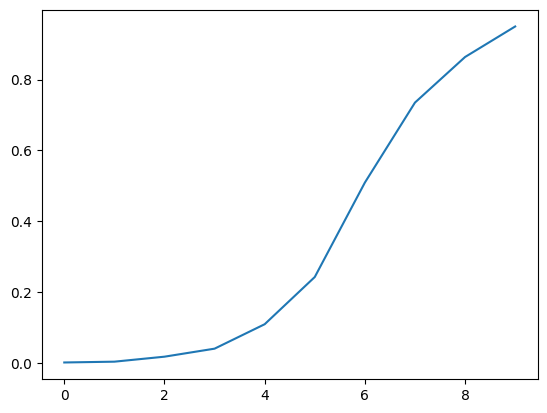

In [14]:
theta = np.array([-2.,-2.,-2.,-5.,-8.,-7.])
y = evo_sim(theta)

plt.plot(y[0:10])

In [22]:
import torch
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from sbi.inference import NPE, simulate_for_sbi

prior_low = torch.tensor([-3.0, -3.0, -3.0, -8.0, -8.0, -8.0])
prior_high = torch.tensor([-1, -1, -1, -4, -4, -4])
prior = BoxUniform(low=prior_low, high=prior_high)
prior, num_parameters, prior_returns_numpy = process_prior(prior)
theta = prior.sample((1000,))
# Check simulator, returns PyTorch simulator able to simulate batches.
simulator = process_simulator(evo_sim, prior, prior_returns_numpy)

# inference
inference = NPE(prior)
theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=1000, num_workers=80)
density_estimator = inference.append_simulations(theta, x).train()
posterior = inference.build_posterior(density_estimator)


  0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 151 epochs.

In [32]:
th = torch.tensor([-2.5, -2.5, -1.5, -6, -6, -6]).reshape(1,-1)
x = simulator(th)
posterior.set_default_x(x).sample((1000,)).mean(0) - th

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

tensor([[ 0.3298,  0.3368, -0.3192, -0.5221, -0.1608,  0.2045]])